Atividade 2 --- Análise de Regressão

### Contexto

Nesta atividade, será realizada a simulação de um conjunto de dados a partir de um modelo de regressão linear simples com parâmetros conhecidos. A partir desses dados, serão conduzidos procedimentos de inferência estatística, incluindo o teste de hipóteses para o coeficiente angular e a construção de intervalos de confiança, além da análise do efeito da centralização da variável explicativa sobre os parâmetros do modelo.

### 1.a) Simule um conjunto de dados com n pares ($Y_i,X_i$), e ajuste o modelo de regressão linear simples.

O modelo considerado é:
$Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i$

In [5]:
# modelo: Y_i = beta_0 + beta_1*X_i + erro_i

set.seed(260329)
n <- 20    # número de observações / tamanho da amostra
beta_0 <- 2.9    # os parâmetros
beta_1 <- 5

X <- runif(n,min = 10, max = 20) 
Erros <- rnorm(n, mean = 0, sd = 5) 
Y <- beta_0 + beta_1 * X + Erros

Foi gerado um conjunto de dados com n=20 observações, considerando o modelo $Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i$ ​ , onde $\varepsilon_i ∼ N( 0 , 𝜎^2 )$, independentes e identicamente distribuídos.

A covariável  $X_i$  foi simulada a partir de uma distribuição uniforme no intervalo [10, 20], enquanto o erro aleatório $\varepsilon_i$  foi gerado a partir de uma distribuição normal com média zero e desvio padrão igual a 5.

A variável resposta  $Y_i$  foi então construída de acordo com o modelo especificado.

---

### b) Teste as hipóteses: $H_0: \beta_1 = 0 $ vs. $H_1: \beta_1 \neq 0$

In [6]:
modelo <- lm(Y ~ X)
summary(modelo)$coef

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),0.065660,5.6440789,0.01163343,9.908460e-01
X,5.190601,0.3790429,13.69396656,5.858565e-11


Foi ajustado um modelo de regressão linear simples para avaliar a relação entre $X$ e $Y$.

As estimações foram:  $\hat{\beta_0} = 0.6 $ $\hat{\beta_1}  = 5.19$

A estatística usada para fazer o teste é $t =\frac{\hat{\beta_1} - \beta_1}{EP(\hat{\beta_1})} = \frac{\hat{\beta_1} - \beta_1}{\sqrt{MSE/\sum (X_i-\bar{X})^2}}$, e essa estatística sob $H_0$ segue uma distribuição $t$ de student com n-2 graus de liberdade


A partir dos resultados do teste feito acima, observa-se que o coeficiente associado a $X$ é estatisticamente significativo, com valor-p (5.86e-11) próximo de zero, .

Dessa forma, rejeitamos $H_0$, há evidência de que $\beta_1 \neq 0$, indicando uma relação linear entre $X$ e $Y$ no range de [10; 20].

---


### c) Determine um intervalo de confiança para $\beta_1$ Interprete o intervalo

Intervalo de confiança para $\beta_1$:

In [7]:
confint(modelo)

,2.5 %,97.5 %
(Intercept),-11.792110,11.923430
X,4.394262,5.986941


O intervalo de confiança de 95% para $\beta_1$, dado por [4.4; 5.9] não contém o valor zero, o que reforça a evidência de que o coeficiente de inclinação é diferente de zero e isso indica que, em média, um aumento unitário em $X$ está associado a um aumento entre 4.4 e 5.9 unidades em $Y$.

Além disso, o intervalo está próximo do valor verdadeiro utilizado na simulação ($\beta_1 = 5$), indicando que o estimador $\hat{\beta_1}$ é adequado neste contexto.

---

### d) Centralize o modelo. Ajuste o modelo centralizado. Interprete $\beta_0 ^ {*}$ e $\beta_1$. Compare os modelos

$X$ centralizado é dado por:


$X^* = X - \bar{X}$

Assim, $Y_i^* = \beta_0^* + \beta_1 X_i^* + \varepsilon_i$

onde $\beta_0^* = \beta_0 + \beta_1 \bar{X}$


Em seguida, ajustou-se um novo modelo de regressão utilizando $X^*$.

In [15]:
X_centralizado <- X - mean(X)

modelo_centralizado <- lm(Y ~ X_centralizado)
summary(modelo_centralizado)$coef

confint(modelo_centralizado)

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),75.816091,1.1208535,67.64140,4.048758e-23
X_centralizado,5.190601,0.3790429,13.69397,5.858565e-11


,2.5 %,97.5 %
(Intercept),73.461266,78.170917
X_centralizado,4.394262,5.986941


As estimações foram:  $\hat{\beta_0^*} = 75.82 $ e $\hat{\beta_1}  = 5.19$

O intervalo de confiança de 95% para $\beta_1$ não mudou, continua sendo [4.4; 5.9]. E sobre a hipótese $H_0: \beta_1 = 0$, é rejeitada por valor p pequeno. Isso é esperado já que o modelo centralizado preserva a inferência a $\beta_1$

Comparando os coeficientes dos dois modelos, observa-se que:

- O estimador $\hat{\beta_1}$ para $\beta_1$ e o seu intervalo de confiança permanecem inalterados nos dois modelos.
- O intercepto é modificado ($\beta_0 \neq \beta_0^*$).

No modelo original, o intercepto representa o valor esperado de $Y$ quando $X = 0$, o que pode não ter interpretação prática, especialmente quando esse valor está fora do intervalo observado. 

Enquanto no modelo centralizado, o intercepto ${\beta_0}^*$ passa a representar o valor esperado de  $Y$ quando $X = \bar{X}$.

Assim, a centralização não altera a inclinação da reta, pois a inclinação continua sendo $\beta_1$ (que representa a variação esperada em $Y$ associado a um aumento unitário em $X$), mas modifica a interpretação do intercepto, tornando-o mais informativo quando o valor médio de $X$ é relevante.

---

Gráfico de dispersão para comparação :

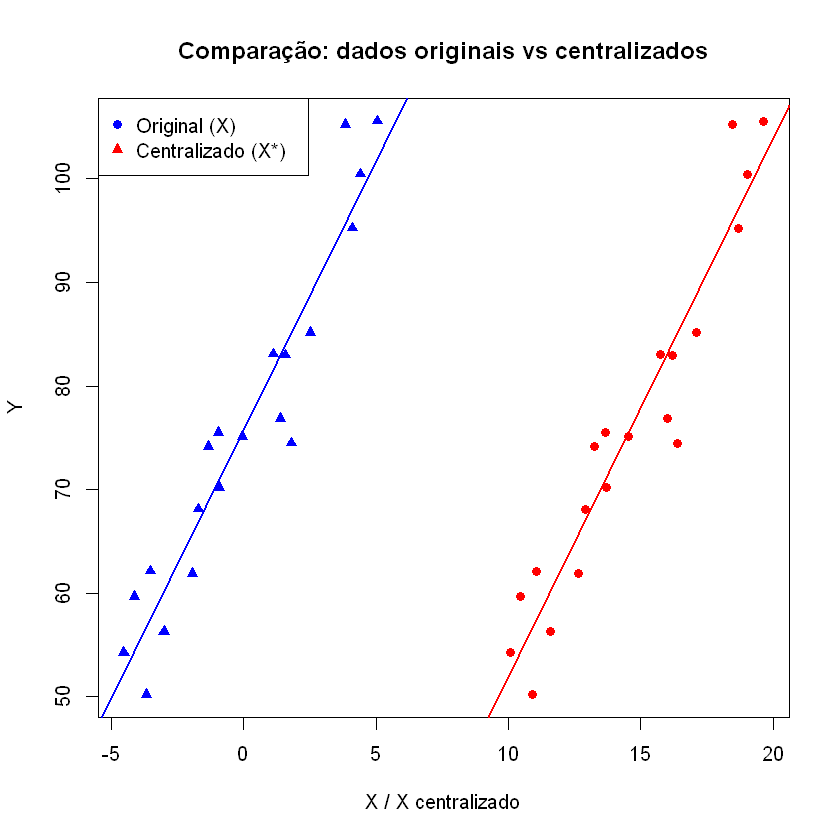

In [13]:
plot(X, Y,
     col = "red",
     pch = 16,
     xlab = "X / X centralizado",
     ylab = "Y",
     main = "Comparação: dados originais vs centralizados",
     xlim = range(c(X, X_centralizado))
)

#pontos do modelo centralizado
points(X_centralizado, Y,
       col = "blue",
       pch = 17)

#retas
abline(modelo, col = "red", lwd = 2)
abline(modelo_centralizado, col = "blue", lwd = 2)


# legenda
legend("topleft",
       legend = c("Original (X)", "Centralizado (X*)"),
       col = c("blue", "red"),
       pch = c(16, 17))